# Data Exploration for Product Search Ranking
This purpose of this notebook is to do data exploration on Home Depot dataset (obtained from Kaggle). Furthermore, the dataset will be split  into train, test and validation set for later training on different method of search ranking.

## Setup

In [35]:
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt

In [36]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

for file in DATA_DIR.iterdir():
    print(file.name)

attributes.csv
product_descriptions.csv
relevance_instructions.docx
sample_submission.csv
test.csv
train.csv


In [37]:
train = pd.read_csv(DATA_DIR / "train.csv", encoding="latin-1")
products = pd.read_csv(
    DATA_DIR / "product_descriptions.csv",
    encoding="latin-1",
)
attributes = pd.read_csv(
    DATA_DIR / "attributes.csv",
    encoding="latin-1",
)

KeyboardInterrupt: 

In [ ]:
train.shape

(74067, 5)

In [ ]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 74067 entries, 0 to 74066
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             74067 non-null  int64  
 1   product_uid    74067 non-null  int64  
 2   product_title  74067 non-null  str    
 3   search_term    74067 non-null  str    
 4   relevance      74067 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 9.1 MB


In [ ]:
train.head()

,id,product_uid,product_title,search_term,relevance
0,2,100001,Simpson Strong-Tie 12-Gauge Angle,angle bracket,3.00
1,3,100001,Simpson Strong-Tie 12-Gauge Angle,l bracket,2.50
2,9,100002,BEHR Premium Textured DeckOver 1-gal. #SC-141 ...,deck over,3.00
3,16,100005,Delta Vero 1-Handle Shower Only Faucet Trim Ki...,rain shower head,2.33
4,17,100005,Delta Vero 1-Handle Shower Only Faucet Trim Ki...,shower only faucet,2.67


In [ ]:
products.shape

(124428, 2)

In [ ]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 124428 entries, 0 to 124427
Data columns (total 2 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   product_uid          124428 non-null  int64
 1   product_description  124428 non-null  str  
dtypes: int64(1), str(1)
memory usage: 101.6 MB


In [ ]:
products.head()

,product_uid,product_description
0,100001,"Not only do angles make joints stronger, they ..."
1,100002,BEHR Premium Textured DECKOVER is an innovativ...
2,100003,Classic architecture meets contemporary design...
3,100004,The Grape Solar 265-Watt Polycrystalline PV So...
4,100005,Update your bathroom with the Delta Vero Singl...


In [ ]:
attributes.shape

(2044803, 3)

In [ ]:
attributes.info()

<class 'pandas.DataFrame'>
RangeIndex: 2044803 entries, 0 to 2044802
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   product_uid  float64
 1   name         str    
 2   value        str    
dtypes: float64(1), str(2)
memory usage: 119.6 MB


In [ ]:
attributes.head()

,product_uid,name,value
0,100001.0,Bullet01,Versatile connector for various 90Â° connectio...
1,100001.0,Bullet02,Stronger than angled nailing or screw fastenin...
2,100001.0,Bullet03,Help ensure joints are consistently straight a...
3,100001.0,Bullet04,Dimensions: 3 in. x 3 in. x 1-1/2 in.
4,100001.0,Bullet05,Made from 12-Gauge steel


## Initial Data Exploration

In [ ]:
print("Total rows:", len(train))
print("Unique queries:", train["search_term"].nunique())
print("Unique products:", train["product_uid"].nunique())

Total rows: 74067
Unique queries: 11795
Unique products: 54667


In [ ]:
# Analyze the distribution of search terms
query_counts = train["search_term"].value_counts()

print(query_counts.describe())

count    11795.000000
mean         6.279525
std          3.424015
min          1.000000
25%          3.000000
50%          7.000000
75%          9.000000
max         16.000000
Name: count, dtype: float64


In [ ]:
query_counts.value_counts().sort_index()

count
1     1399
2      943
3      837
4      695
5      868
6     1038
7     1248
8     1318
9     1203
10     983
11     611
12     357
13     191
14      71
15      24
16       9
Name: count, dtype: int64

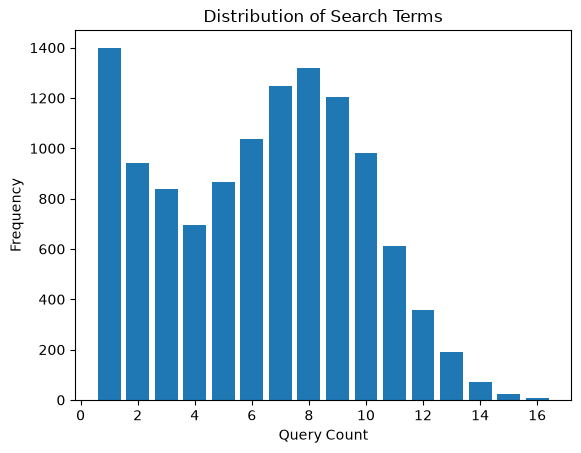

In [ ]:
plt.bar(query_counts.value_counts().sort_index().index, query_counts.value_counts().sort_index())
plt.xlabel("Query Count")
plt.ylabel("Frequency")
plt.title("Distribution of Search Terms")
plt.show()

In [ ]:
# Check for missing values in the dataset
print(train.isna().sum())

id               0
product_uid      0
product_title    0
search_term      0
relevance        0
dtype: int64


In [ ]:
print(products.isna().sum())

product_uid            0
product_description    0
dtype: int64


In [ ]:
print(attributes.shape)
print(attributes.isna().sum())

(2044803, 3)
product_uid     155
name            155
value          6422
dtype: int64


Below is an example of search term and its relevance against multiple products

In [ ]:
example_query = query_counts[query_counts >= 5].index[0]

train.loc[
    train["search_term"] == example_query,
    ["search_term", "product_title", "relevance"]
].sort_values("relevance", ascending=False)

,search_term,product_title,relevance
704,metal sheet,MD Building Products 12 in. x 24 in. 22-Gauge ...,3.00
809,metal sheet,MD Building Products 1 ft. x 2 ft. Satin Nick ...,3.00
1598,metal sheet,Everbilt 6 in. x 18 in. 21-Gauge Aluminum Meta...,3.00
3449,metal sheet,MD Hobby and Craft 12 in. x 30 in. Rolled Bras...,3.00
3673,metal sheet,Crown Bolt 12 in. x 18 in. 22-Gauge Metal Sheet,3.00
5786,metal sheet,MD Building Products 24 in. x 36 in. Cloverlea...,3.00
1500,metal sheet,Everbilt 1/4 in. x 4 in. x 12 in. Plain Steel ...,2.67
767,metal sheet,Crown Bolt 24 in. x 36 in. 26-Gauge Zinc Metal...,2.67
1951,metal sheet,MD Building Products 36 in. x 36 in. Plain Alu...,2.67
4203,metal sheet,MD Building Products 12 in. x 24 in. Chalkboar...,2.33


In [ ]:
train["relevance"].value_counts().sort_index()

relevance
1.00     2105
1.25        4
1.33     3006
1.50        5
1.67     6780
1.75        9
2.00    11730
2.25       11
2.33    16060
2.50       19
2.67    15202
2.75       11
3.00    19125
Name: count, dtype: int64

Text(0.5, 0, 'Relevance Score')

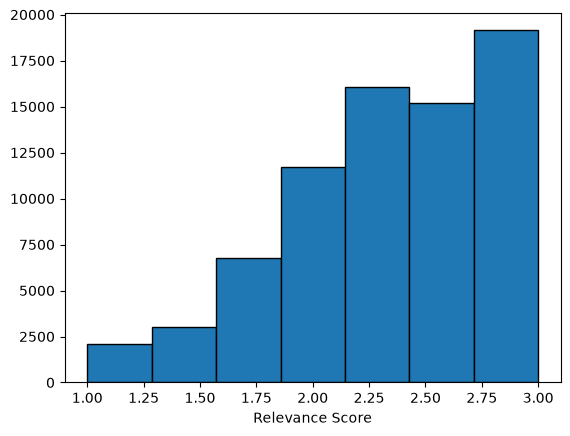

In [ ]:
plt.hist(train["relevance"], bins=7, edgecolor="black") # bins=7 since there are 7 scores with high count
plt.xlabel("Relevance Score")

In [ ]:
train_products = set(train["product_uid"])
description_products = set(products["product_uid"])

print(
    "Train products missing descriptions:",
    len(train_products - description_products)
)

Train products missing descriptions: 0


## Query Analysis
In order to do learning to rank, we need to have each search term different scores against different product. Below, we find how many unique relevance scores each search term in the dataset.

In [ ]:
query_stats = train.groupby("search_term").agg(
    num_products=("product_uid", "nunique"),
    num_relevance_scores=("relevance", "nunique"),
)

ranking_queries = query_stats[(query_stats["num_relevance_scores"] > 1)
                              & (query_stats["num_products"] > 1)]
print(ranking_queries)

                            num_products  num_relevance_scores
search_term                                                   
$ hole saw                             8                     4
. exterior floor stain                 3                     3
.105 trimmer line                      3                     2
.110 wire connector                    9                     4
.440 metal screws                      8                     5
...                                  ...                   ...
zip it                                 4                     3
zone valve switch                      6                     3
zoned temperature monitors            10                     5
zurn ez-flush                          3                     2
zwave switch                           7                     4

[9960 rows x 2 columns]


Below are queries with only single unique score.

In [ ]:
query_stats[(query_stats["num_relevance_scores"] == 1)
                              & (query_stats["num_products"] > 1)]

,num_products,num_relevance_scores
search_term,,
.8 mulch rubber vigoro,2,1
0.5 drip tubing,7,1
019 070 vanity,3,1
1 1/4 PVC Tee,8,1
1 1/4 finish nails,5,1
...,...,...
winix plasmawave 6300 air cleaner model,2,1
wireless security caamera,8,1
wooden rocking chairs,2,1


### Attributes Analysis

In [ ]:
attributes["name"].value_counts().head(30)

name
MFG Brand Name                 86250
Bullet02                       86248
Bullet03                       86226
Bullet04                       86174
Bullet01                       85940
Product Width (in.)            61137
Bullet05                       60529
Product Height (in.)           54698
Product Depth (in.)            53652
Product Weight (lb.)           45175
Bullet06                       44901
Color Family                   41508
Bullet07                       34349
Material                       31500
Color/Finish                   28564
Bullet08                       26645
Certifications and Listings    24583
Bullet09                       20567
Assembled Height (in.)         18299
Assembled Width (in.)          18263
Assembled Depth (in.)          18198
Product Length (in.)           16705
Bullet10                       14763
Indoor/Outdoor                 12939
Bullet11                       11784
Commercial / Residential        9530
Bullet12                        8

In [ ]:
print("Unique attribute names:", attributes["name"].nunique())

Unique attribute names: 5410


### Canonical Product Titles

Some products appear with slightly different titles across query records.
We construct a single canonical title per product by selecting the longest
observed title.

In [ ]:
title_counts = train.groupby("product_uid")["product_title"].nunique()

print(title_counts.describe())
print("Products with multiple titles:", (title_counts > 1).sum())

count    54667.000000
mean         1.000274
std          0.016563
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: product_title, dtype: float64
Products with multiple titles: 15


In [ ]:
all_titles = train[["product_uid", "product_title"]].copy()


all_titles = all_titles.drop_duplicates()

canonical_titles = (
    all_titles.assign(
        title_length=all_titles["product_title"].str.len()
    )
    .sort_values(
        ["product_uid", "title_length"],
        ascending=[True, False],
    )
    .drop_duplicates(
        subset="product_uid",
        keep="first",
    )
    .drop(columns="title_length")
)

## Attribute Preprocessing

In [ ]:
attributes_clean = attributes.dropna().copy()

attributes_clean["name"] = attributes_clean["name"].str.strip()
attributes_clean["value"] = attributes_clean["value"].astype(str).str.strip()

attributes_clean = attributes_clean[
    (attributes_clean["name"] != "")
    & (attributes_clean["value"] != "")
]

attributes_clean = attributes_clean.drop_duplicates()
print("Total rows:", len(attributes_clean))
print(
    "Rows removed:",
    len(attributes) - len(attributes_clean)
)

Total rows: 2038381
Rows removed: 6422


In [ ]:
attributes_clean["attribute"] = (
    attributes_clean["name"]
    + ": "
    + attributes_clean["value"]
)
attributes_clean.head(3)

,product_uid,name,value,attribute
0,100001.0,Bullet01,Versatile connector for various 90Â° connectio...,Bullet01: Versatile connector for various 90Â°...
1,100001.0,Bullet02,Stronger than angled nailing or screw fastenin...,Bullet02: Stronger than angled nailing or scre...
2,100001.0,Bullet03,Help ensure joints are consistently straight a...,Bullet03: Help ensure joints are consistently ...


In [ ]:
attribute_text = (
    attributes_clean
    .groupby("product_uid")["attribute"]
    .agg(". ".join)
    .reset_index(name="attribute_text")
)
attribute_text.head(3)

,product_uid,attribute_text
0,100001.0,Bullet01: Versatile connector for various 90Â°...
1,100002.0,"Application Method: Brush,Roller,Spray. Assemb..."
2,100003.0,Built-in flange: Yes. Bullet01: Slightly narro...


In [ ]:
attribute_text[
    attribute_text["product_uid"] == 110074
]["attribute_text"].iloc[0]

'Batteries Included: Yes. Battery Amp Hours: 1.5. Battery Power Type: Lithium Ion. Battery Size: Lithium Ion. Bullet01: Includes: DEWALT DCD771 1/2 in. drill/driver and a DCF885 1/4 in. impact driver and tough case. Bullet02: Delivers 2 speeds (0-450 and 1,500 rpm) for a range of fastening and drilling applications. Bullet03: 1/2 in. single sleeve ratcheting chuck provides tight bit gripping strength. Bullet04: DCF885 1-handed loading 1/4 in. hex chuck accepts 1 in. bit tips. Bullet05: Compact (5.55 in. front to back), lightweight (2.8 lb.) design fits into tight areas. Bullet06: 3 LED lights with 20 second delay after trigger release, provide visibility without shadows. Bullet07: Tough case fits into the metal carrier (not included) with adjustable foldable brackets which allows for tailored configuration. Bullet08: Central locking mechanism secures the tough case to the frame (not included). Bullet09: Integrated water seal in every tough case for protection of contents and long life 

Check whether the number of characters for a single product is too long or not.

In [ ]:
attribute_text["text_length"] = (
    attribute_text["attribute_text"].str.len()
)

attribute_text["text_length"].describe()

count    86263.000000
mean       970.078029
std        526.225565
min        159.000000
25%        608.000000
50%        837.000000
75%       1194.000000
max       6148.000000
Name: text_length, dtype: float64

In [ ]:
attribute_text = attribute_text.drop(columns="text_length")

Now we combine the title, description and attribute for each product.

In [ ]:
product_catalog = canonical_titles.copy()
product_catalog = product_catalog.merge(
    products,
    on="product_uid",
    how="left",
)

product_catalog = product_catalog.merge(
    attribute_text,
    on="product_uid",
    how="left",
)

In [ ]:
product_catalog.head(3)

,product_uid,product_title,product_description,attribute_text
0,100001,Simpson Strong-Tie 12-Gauge Angle,"Not only do angles make joints stronger, they ...",Bullet01: Versatile connector for various 90Â°...
1,100002,BEHR Premium Textured DeckOver 1-gal. #SC-141 ...,BEHR Premium Textured DECKOVER is an innovativ...,"Application Method: Brush,Roller,Spray. Assemb..."
2,100005,Delta Vero 1-Handle Shower Only Faucet Trim Ki...,Update your bathroom with the Delta Vero Singl...,Bath Faucet Type: Combo Tub and Shower. Built-...


In [ ]:
# Check for missing values in the product catalog
product_catalog.isna().sum()

product_uid                0
product_title              0
product_description        0
attribute_text         16263
dtype: int64

In [ ]:
# missing attribute_text values are filled with empty strings to avoid issues in downstream processing
product_catalog["attribute_text"] = (
    product_catalog["attribute_text"].fillna("")
)

Now we add product text which contains all of information in a single cell.

In [ ]:
product_catalog["product_text"] = (
    "Title: "
    + product_catalog["product_title"]
    + ". Description: "
    + product_catalog["product_description"]
    + ". Attributes: "
    + product_catalog["attribute_text"]
)

In [ ]:
product_catalog.head(3)

,product_uid,product_title,product_description,attribute_text,product_text
0,100001,Simpson Strong-Tie 12-Gauge Angle,"Not only do angles make joints stronger, they ...",Bullet01: Versatile connector for various 90Â°...,Title: Simpson Strong-Tie 12-Gauge Angle. Desc...
1,100002,BEHR Premium Textured DeckOver 1-gal. #SC-141 ...,BEHR Premium Textured DECKOVER is an innovativ...,"Application Method: Brush,Roller,Spray. Assemb...",Title: BEHR Premium Textured DeckOver 1-gal. #...
2,100005,Delta Vero 1-Handle Shower Only Faucet Trim Ki...,Update your bathroom with the Delta Vero Singl...,Bath Faucet Type: Combo Tub and Shower. Built-...,Title: Delta Vero 1-Handle Shower Only Faucet ...


Save the product_catalog as parquet.

In [ ]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

product_catalog.to_parquet(
    PROCESSED_DIR / "product_catalog.parquet",
    index=False,
)

## Query Group Analysis

In [ ]:
query_group_sizes = (
    train.groupby("search_term")
    .size()
)
print(
    query_group_sizes.value_counts()
    .sort_index()
)

1     1399
2      943
3      837
4      695
5      868
6     1038
7     1248
8     1318
9     1203
10     983
11     611
12     357
13     191
14      71
15      24
16       9
Name: count, dtype: int64


In [ ]:
print("Total queries:", len(query_group_sizes))
print(
    "Queries with >=2 products:",
    (query_group_sizes >= 2).sum()
)
print(
    "Queries with >=3 products:",
    (query_group_sizes >= 3).sum()
)

Total queries: 11795
Queries with >=2 products: 10396
Queries with >=3 products: 9453


## Query-Based Train/Validation/Test Split

Because this is a search ranking problem, rows from the same search query
should not be split across train, validation, and test sets.

We therefore split at the query level to prevent query-level leakage.

In [ ]:
ranking_data = train[
    train["search_term"].isin(
        query_group_sizes[
            query_group_sizes >= 2
        ].index
    )
].copy()

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

unique_queries = set(ranking_data["search_term"])

train_queries, temp_queries = train_test_split(
    list(unique_queries),
    test_size=0.20,
    random_state=RANDOM_STATE,
)

val_queries, test_queries = train_test_split(
    temp_queries,
    test_size=0.50,
    random_state=RANDOM_STATE,
)

In [ ]:
train_split = ranking_data[
    ranking_data["search_term"].isin(train_queries)
].copy()

val_split = ranking_data[
    ranking_data["search_term"].isin(val_queries)
].copy()

test_split = ranking_data[
    ranking_data["search_term"].isin(test_queries)
].copy()

In [ ]:
print("Train queries:", train_split["search_term"].nunique())
print("Validation queries:", val_split["search_term"].nunique())
print("Test queries:", test_split["search_term"].nunique())

print()

print("Train rows:", len(train_split))
print("Validation rows:", len(val_split))
print("Test rows:", len(test_split))

Train queries: 8316
Validation queries: 1040
Test queries: 1040

Train rows: 57854
Validation rows: 7395
Test rows: 7419


### Dataset Split and Relevance Analysis

In [ ]:
def relevance_summary(df):
    return {
        "mean": df["relevance"].mean(),
        "std": df["relevance"].std(),
        "min": df["relevance"].min(),
        "median": df["relevance"].median(),
        "max": df["relevance"].max(),
    }

for name, df in {
    "train": train_split,
    "validation": val_split,
    "test": test_split,
}.items():
    print(f"\n{name.upper()}")
    print(relevance_summary(df))


TRAIN
{'mean': np.float64(2.38), 'std': np.float64(0.53), 'min': np.float64(1.0), 'median': np.float64(2.33), 'max': np.float64(3.0)}

VALIDATION
{'mean': np.float64(2.39), 'std': np.float64(0.53), 'min': np.float64(1.0), 'median': np.float64(2.33), 'max': np.float64(3.0)}

TEST
{'mean': np.float64(2.38), 'std': np.float64(0.53), 'min': np.float64(1.0), 'median': np.float64(2.33), 'max': np.float64(3.0)}


In [ ]:
for name, df in {
    "train": train_split,
    "validation": val_split,
    "test": test_split,
}.items():
    print(f"\n{name.upper()} relevance distribution (%)")
    print(
        df["relevance"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )


TRAIN relevance distribution (%)
relevance
1.00     2.87
1.25     0.00
1.33     4.06
1.50     0.01
1.67     9.27
1.75     0.01
2.00    15.88
2.25     0.02
2.33    21.62
2.50     0.03
2.67    20.49
2.75     0.01
3.00    25.73
Name: proportion, dtype: float64

VALIDATION relevance distribution (%)
relevance
1.00     2.91
1.33     3.96
1.67     8.72
2.00    15.51
2.33    21.97
2.50     0.01
2.67    19.96
2.75     0.04
3.00    26.91
Name: proportion, dtype: float64

TEST relevance distribution (%)
relevance
1.00     2.67
1.25     0.03
1.33     4.31
1.67     8.91
2.00    15.99
2.25     0.03
2.33    21.61
2.50     0.01
2.67    21.07
2.75     0.03
3.00    25.35
Name: proportion, dtype: float64


Save the split into parquet.

In [ ]:
train_split.to_parquet(
    PROCESSED_DIR / "train.parquet",
    index=False,
)

val_split.to_parquet(
    PROCESSED_DIR / "validation.parquet",
    index=False,
)

test_split.to_parquet(
    PROCESSED_DIR / "test.parquet",
    index=False,
)